# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Queremos prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

# **Preparação dos Dados**

**Exploração e Limpeza:** Vamos analisar e limpar os dados para garantir que estejam prontos para a modelagem.



In [57]:
# bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# carregando dataset
base = pd.read_csv('marketing_campaign.csv', delimiter=';')

In [3]:
# Visualizando base
base.head(10)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
5,1967,Master,Together,62513.0,0,16,520,42,98,0,42,14,10,6,0,1
6,1971,Graduation,Divorced,55635.0,0,34,235,65,164,50,49,27,7,6,0,1
7,1985,PhD,Married,33454.0,1,32,76,10,56,3,1,23,4,8,0,1
8,1974,PhD,Together,30351.0,1,19,14,0,24,3,3,2,2,9,0,0
9,1950,PhD,Together,5648.0,1,68,28,0,6,1,1,13,0,20,0,0


In [4]:
 # Traduzindo colunas para o portugues para facilitar as analises
 base = base.rename(columns={
    'Year_Birth': 'ano_nascimento',
    'Education': 'nivel_de_escolaridade',
    'Marital_Status': 'estado_civil',
    'Income': 'renda_anual_da_familia',
    'Kidhome': 'numero_de_criancas',
    'Recency': 'ultima_compra',
    'Complain': 'reclamacoes',
    'MntMeatProducts': 'gasto_em_carnes',
    'MntWines': 'gasto_em_vinhos',
    'MntFruits': 'gasto_em_frutas',
    'MntFishProducts': 'gasto_em_peixes',
    'MntSweetProducts': 'gasto_em_doces',
    'MntGoldProds': 'gasto_produtos_ouro',
    'NumStorePurchases': 'compras_loja',
    'NumDealsPurchases': 'compras_com_desconto',
    'NumWebVisitsMonth': 'visitas_site_mes',
    'WebPurchases': 'compras_site_empresa'})

In [5]:
# Verificando tipo de dados
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ano_nascimento          2240 non-null   int64  
 1   nivel_de_escolaridade   2240 non-null   object 
 2   estado_civil            2240 non-null   object 
 3   renda_anual_da_familia  2216 non-null   float64
 4   numero_de_criancas      2240 non-null   int64  
 5   ultima_compra           2240 non-null   int64  
 6   gasto_em_vinhos         2240 non-null   int64  
 7   gasto_em_frutas         2240 non-null   int64  
 8   gasto_em_carnes         2240 non-null   int64  
 9   gasto_em_peixes         2240 non-null   int64  
 10  gasto_em_doces          2240 non-null   int64  
 11  gasto_produtos_ouro     2240 non-null   int64  
 12  compras_loja            2240 non-null   int64  
 13  visitas_site_mes        2240 non-null   int64  
 14  reclamacoes             2240 non-null   

In [6]:
# verificar valores nulos
base.isnull().values.any()

np.True_

In [7]:
base.isnull().sum()

,0
ano_nascimento,0
nivel_de_escolaridade,0
estado_civil,0
renda_anual_da_familia,24
numero_de_criancas,0
ultima_compra,0
gasto_em_vinhos,0
gasto_em_frutas,0
gasto_em_carnes,0
gasto_em_peixes,0


Existem valores nulos na coluna 'Renda anual da família do cliente'.

### Tratando valores nulos na coluna 'renda_anual_da_familia'

Vamos preencher os 24 valores nulos da coluna `renda_anual_da_familia` com a mediana para evitar distorções causadas por possíveis outliers e manter o maior número de dados possível.

In [8]:
# Calculando a mediana da coluna 'renda_anual_da_familia'
median_income = base['renda_anual_da_familia'].median()

In [9]:
# Preenchendo os valores nulos com a mediana
base['renda_anual_da_familia'] = base['renda_anual_da_familia'].fillna(median_income)

In [10]:
# Verificando novamente se há valores nulos na coluna 'renda_anual_da_familia'
print(f"Número de valores nulos em 'renda_anual_da_familia' após imputação: {base['renda_anual_da_familia'].isnull().sum()}")

Número de valores nulos em 'renda_anual_da_familia' após imputação: 0


In [11]:
# Verificando Outliers
base.describe()

,ano_nascimento,renda_anual_da_familia,numero_de_criancas,ultima_compra,gasto_em_vinhos,gasto_em_frutas,gasto_em_carnes,gasto_em_peixes,gasto_em_doces,gasto_produtos_ouro,compras_loja,visitas_site_mes,reclamacoes,compras_site_empresa
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52237.975446,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25037.955891,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35538.750000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68289.750000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


### Identificando Outliers com Box Plots

Vamos gerar box plots para as colunas numéricas para visualizar a distribuição dos dados e identificar possíveis outliers.

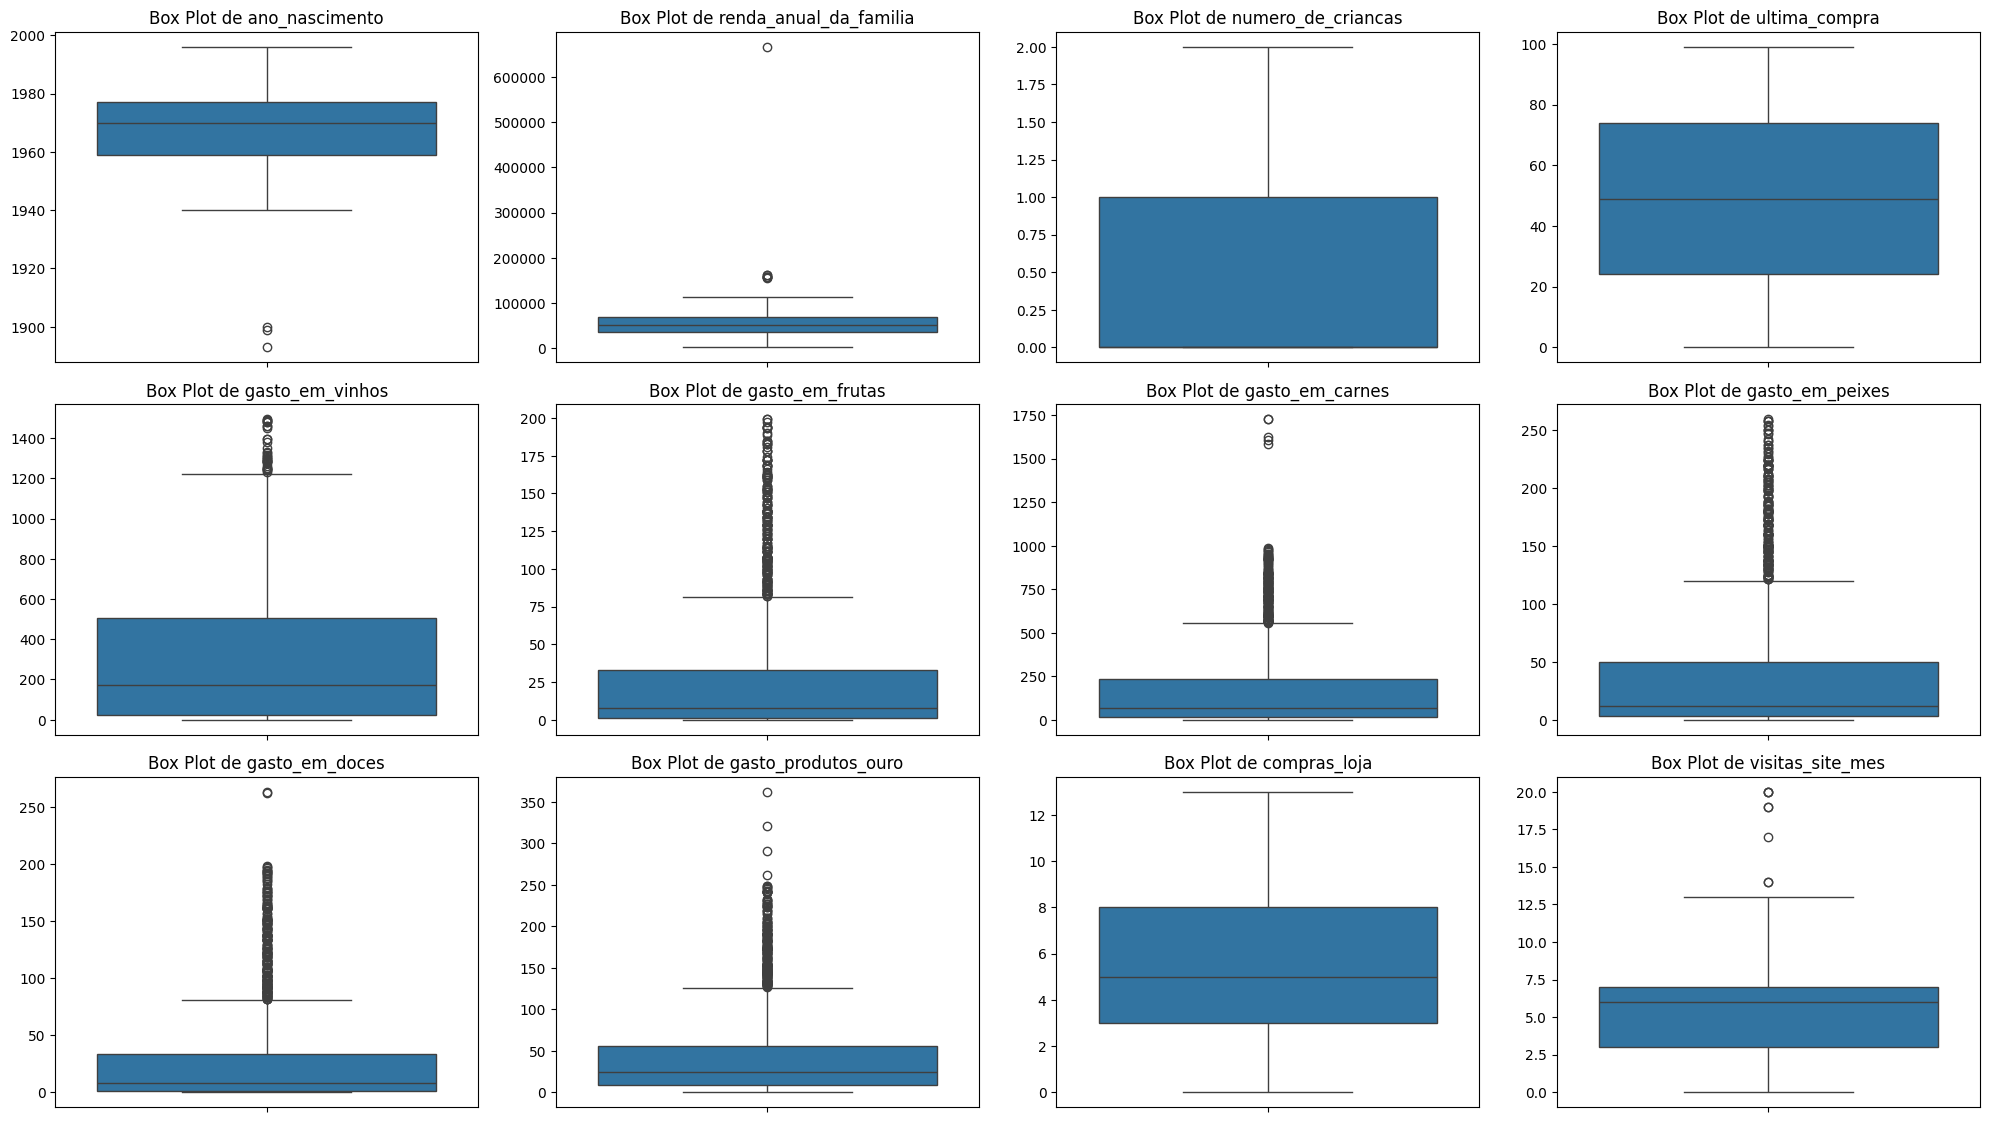

In [12]:
# Selecionando apenas as colunas numéricas para o box plot
# Garantimos que a 'base' já está processada com nomes em português e nulos tratados.
numerical_cols = base.select_dtypes(include=['int64', 'float64']).columns

# Excluindo 'reclamacoes' e 'compras_site_empresa' se forem tratadas como binárias/categóricas para este propósito
numerical_cols = numerical_cols.drop(['reclamacoes', 'compras_site_empresa'], errors='ignore')

# Plotando BoxPlot
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Ajuste o layout conforme o número de colunas
    sns.boxplot(y=base[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

## Analise de Box Plot:

* **Renda Anual da Família (renda_anual_da_familia):** O box plot para esta variável revela a presença de diversos outliers, especialmente valores de renda muito altos. Embora esses valores possam parecer extremos em comparação com a maioria, foi decidido mantê-los, pois representam rendas reais de clientes e podem indicar segmentos de alto valor.

* **Gastos em Produtos (gasto_em_vinhos, gasto_em_frutas, gasto_em_carnes, gasto_em_peixes, gasto_em_doces, gasto_produtos_ouro):** Todos os box plots relacionados aos gastos com diferentes categorias de produtos mostram uma cauda longa de valores superiores, indicando clientes que gastam significativamente mais do que a média. Esses são considerados outliers, mas, assim como a renda, foi decidido mantê-los. Eles representam comportamentos de compra autênticos e são importantes para identificar clientes de alto consumo.

* **Visitas ao Site por Mês (visitas_site_mes):** O box plot para esta variável também exibe alguns valores atípicos, onde certos clientes realizam um número muito elevado de visitas ao site em um mês. Esses pontos foram mantidos, pois refletem o engajamento real do cliente com a plataforma online, seja para pesquisa intensa ou para compras frequentes.

* **Ano de Nascimento (ano_nascimento):** Foi identificamos alguns outliers onde os anos de nascimento eram muito antigos (por exemplo, o valor mínimo era 1893). Isso resultaria em clientes com mais de 100 anos na época de referência dos dados (2014), o que é biologicamente possível, mas estatisticamente improvável para uma amostra de clientes e frequentemente indica um erro de digitação ou um valor irreal para a análise.
Então vamos optar por tratar esses outliers por achar essa variavel importante para futuras analises.

### Tratando Outliers em `Ano de Nascimento` e Criando a Coluna `Idade`

Vamos primeiro focar nos outliers de `Ano de Nascimento`, que parecem ser erros de dados, e criar a coluna `Idade` a partir dela.

In [13]:
#visualizando as ocorrencias onde ano_nascimento < 1914
base[base['ano_nascimento'] < 1914]

,ano_nascimento,nivel_de_escolaridade,estado_civil,renda_anual_da_familia,numero_de_criancas,ultima_compra,gasto_em_vinhos,gasto_em_frutas,gasto_em_carnes,gasto_em_peixes,gasto_em_doces,gasto_produtos_ouro,compras_loja,visitas_site_mes,reclamacoes,compras_site_empresa
192,1900,2n Cycle,Divorced,36640.0,1,99,15,6,8,7,4,25,2,5,1,0
239,1893,2n Cycle,Single,60182.0,0,23,8,0,5,7,0,2,2,4,0,0
339,1899,PhD,Together,83532.0,0,36,755,144,562,104,64,224,4,1,0,1


In [14]:
print("Porcentagem de registros onde 'ano_nascimento' < 1914:",
      (len(base[base['ano_nascimento'] < 1914]) / len(base)) * 100)

Porcentagem de registros onde 'ano_nascimento' < 1914: 0.13392857142857142


In [15]:
import datetime

# Definir o ano de referência para o cálculo da idade (assumindo que os dados são de 2014)
reference_year = 2014

# Identificar e remover os outliers em 'ano_nascimento'
# Assumimos que anos de nascimento muito antigos (resultando em idade > 100) são erros de cadastro.
# O ano de nascimento mínimo para uma idade de até 100 em 2014 seria 1914 (2014 - 100).
initial_rows = base.shape[0]
base = base[base['ano_nascimento'] >= 1914].copy() # Use .copy() para evitar SettingWithCopyWarning
removed_rows = initial_rows - base.shape[0]
print(f"Foram removidas {removed_rows} linhas com 'ano_nascimento' antes de 1914 (considerado outlier).")

# Criar a coluna 'idade'
base['idade'] = reference_year - base['ano_nascimento']

# Excluir a coluna 'ano_nascimento'
base = base.drop('ano_nascimento', axis=1)

print("Coluna 'idade' criada e 'ano_nascimento' removida.")
print(base[['idade']].describe())


Foram removidas 3 linhas com 'ano_nascimento' antes de 1914 (considerado outlier).
Coluna 'idade' criada e 'ano_nascimento' removida.
             idade
count  2237.000000
mean     45.098346
std      11.701917
min      18.000000
25%      37.000000
50%      44.000000
75%      55.000000
max      74.000000


In [16]:
# Verificando a base
base.head()

,nivel_de_escolaridade,estado_civil,renda_anual_da_familia,numero_de_criancas,ultima_compra,gasto_em_vinhos,gasto_em_frutas,gasto_em_carnes,gasto_em_peixes,gasto_em_doces,gasto_produtos_ouro,compras_loja,visitas_site_mes,reclamacoes,compras_site_empresa,idade
0,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1,57
1,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0,60
2,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1,49
3,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0,30
4,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1,33


### Análise de Variáveis Categóricas

Vamos visualizar a distribuição das variáveis categóricas `nivel_de_escolaridade` e `estado_civil ` para entender a composição dos clientes.

/tmp/ipykernel_162/4275554193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=base, x='nivel_de_escolaridade', palette='viridis')
/tmp/ipykernel_162/4275554193.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=base, x='estado_civil', palette='viridis')


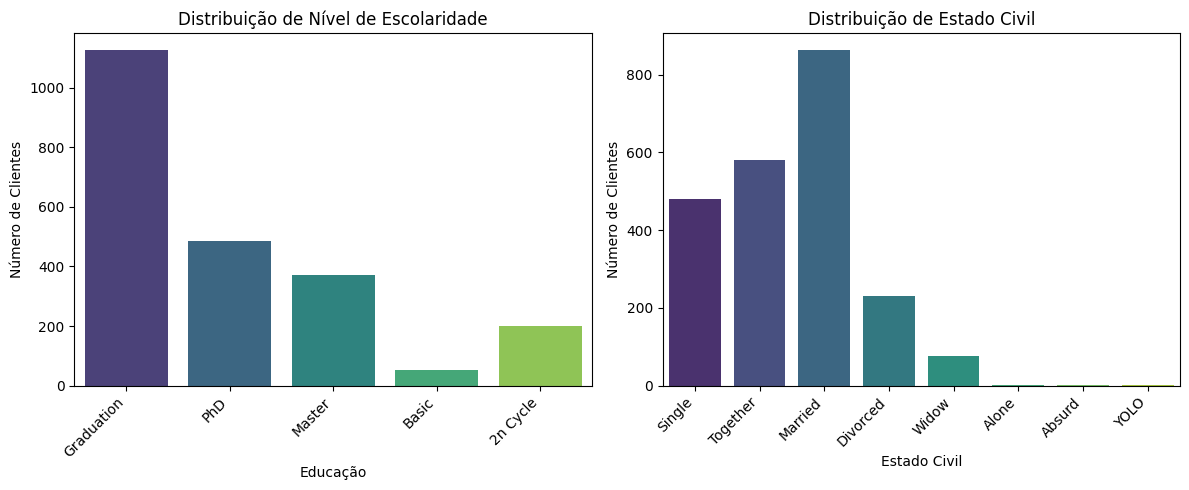

In [17]:
# Plotando gráfico para visualizar variáveis categóricas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=base, x='nivel_de_escolaridade', palette='viridis')
plt.title('Distribuição de Nível de Escolaridade')
plt.xlabel('Educação')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.countplot(data=base, x='estado_civil', palette='viridis')
plt.title('Distribuição de Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

A análise do perfil educacional revela que o grupo de Graduados supera significativamente as demais categorias em volume. Interessantemente, os níveis de Mestrado (Master) e Doutorado (PhD) apresentam distribuições similares entre si, enquanto o nível Básico detém a menor representatividade na base de clientes. No que tange ao estado civil, observa-se uma predominância de clientes casados, seguidos de perto por aqueles que vivem em união estável (together) ou são solteiros."

# **Pré-processamento**



### Análise de Correlação

Vamos calcular e visualizar a matriz de correlação entre as variáveis numéricas para identificar padrões e possíveis redundâncias.

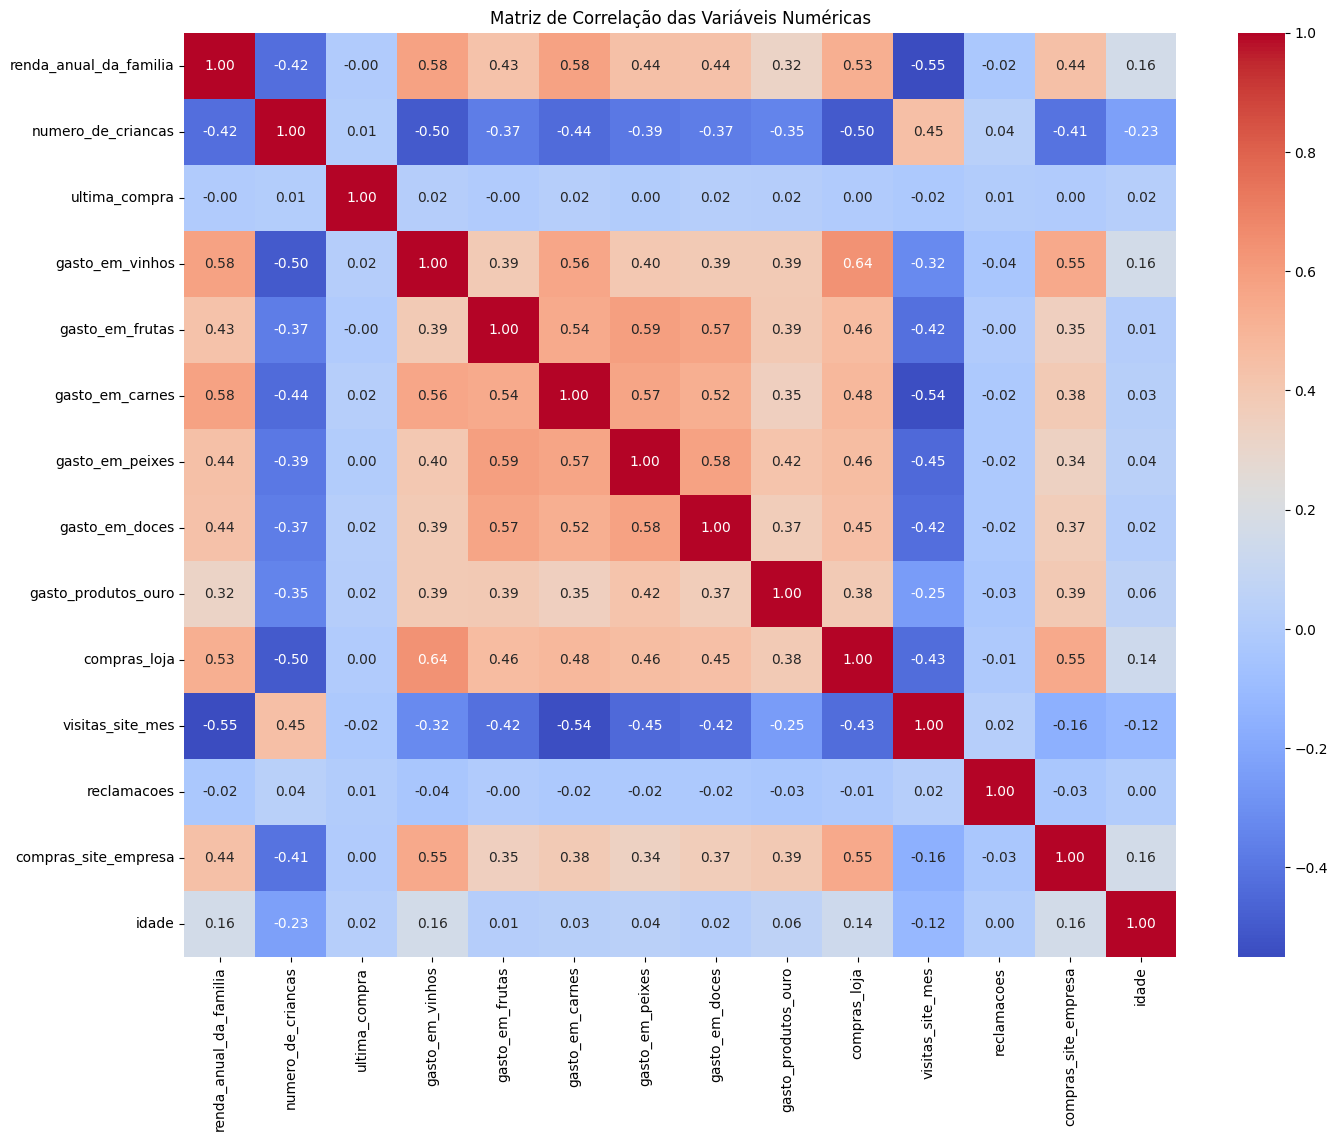

Matriz de Correlação das Variáveis Numéricas:
                        renda_anual_da_familia  numero_de_criancas  \
renda_anual_da_familia                1.000000           -0.424887   
numero_de_criancas                   -0.424887            1.000000   
ultima_compra                        -0.003205            0.007544   
gasto_em_vinhos                       0.576731           -0.496367   
gasto_em_frutas                       0.428191           -0.372488   
gasto_em_carnes                       0.577524           -0.437059   
gasto_em_peixes                       0.437214           -0.387536   
gasto_em_doces                        0.435918           -0.370656   
gasto_produtos_ouro                   0.321082           -0.349633   
compras_loja                          0.527346           -0.500387   
visitas_site_mes                     -0.549429            0.447641   
reclamacoes                          -0.024866            0.036283   
compras_site_empresa                  0.4377

In [18]:
# Selecionar apenas as colunas numéricas para a matriz de correlação
numerical_cols = base.select_dtypes(include=['int64', 'float64']).columns

# Calcular a matriz de correlação
correlation_matrix = base[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

print("Matriz de Correlação das Variáveis Numéricas:")
print(correlation_matrix)

## Variáveis com Correlação Forte com 'Compras no Site da Empresa' (compras_site_empresa - variável alvo):

### Correlações Positivas Fortes:

* gasto_em_vinhos (0.55): Clientes que gastam mais em vinhos tendem a fazer significativamente mais compras no site.
* renda_anual_da_familia (0.44): Uma renda anual mais alta está associada a um maior número de compras no site.
* compras_loja (0.42): Clientes que compram mais nas lojas físicas também mostram uma tendência a comprar mais no site, sugerindo um perfil de cliente mais engajado ou com maior poder de compra geral.
* gasto_em_carnes (0.38), gasto_em_doces (0.37),  gasto_produtos_ouro (0.35), gasto_em_frutas (0.35), gasto_em_peixes (0.34): Todos os gastos em produtos mostram correlações positivas moderadas com compras no site. Isso indica que clientes que consomem mais tendem a comprar mais online.

### Correlações Negativas Fortes:

* numero_de_criancas (-0.41): Clientes com mais crianças tendem a fazer menos compras no site. Isso pode indicar uma priorização de gastos ou menos tempo para compras online.
* visitas_site_mes (-0.35): Curiosamente, mais visitas ao site não se correlacionam positivamente com mais compras no site. Na verdade, há uma correlação negativa moderada. Isso pode sugerir que clientes que visitam o site frequentemente podem estar apenas pesquisando ou comparando preços, mas não convertendo em compras, ou que clientes de alta conversão já sabem o que querem e compram mais diretamente.
### Outras Observações Importantes:
* renda_anual_da_familia: Possui fortes correlações positivas com a maioria dos gasto_em_produtos (vinhos, carnes, etc.) e compras_loja. Por outro lado, tem uma forte correlação negativa com visitas_site_mes e numero_de_criancas. Isso sugere que clientes com alta renda gastam mais e têm menos filhos, e talvez sejam mais eficientes em suas compras online, necessitando de menos visitas ao site.

* numero_de_criancas: Apresenta correlações negativas com todos os tipos de gastos em produtos e com compras_loja. Em contrapartida, tem uma correlação positiva moderada com visitas_site_mes. Isso reforça a ideia de que famílias com crianças podem ter padrões de consumo diferentes, talvez com menor poder de compra para itens de luxo ou mais tempo dedicado à pesquisa online antes de uma compra.

* ultima_compra: As correlações com quase todas as outras variáveis são muito próximas de zero. Isso indica que o tempo desde a última compra do cliente não é um forte preditor para as outras características ou para a intenção de compra online neste dataset.

* reclamacoes: Similar à ultima_compra, a coluna reclamacoes mostra correlações muito baixas com todas as outras variáveis. Isso sugere que ter reclamado nos últimos 2 anos não tem um impacto significativo nos padrões de gasto ou na intenção de compra online.

* idade: A correlação da idade com compras_site_empresa é muito baixa (0.015), indicando que a idade, por si só, não é um forte preditor da intenção de compra online. No entanto, possui correlações positivas fracas com renda_anual_da_familia, gasto_em_vinhos e compras_loja.

* Inter-correlações entre Gastos: Os gastos em diferentes categorias de produtos (vinhos, frutas, carnes, etc.) são consistentemente correlacionados positivamente entre si (muitas acima de 0.5). Isso é esperado, pois clientes que gastam muito em um tipo de produto geralmente são grandes consumidores e gastam muito em outros também. Isso pode ser um indicador de um segmento de clientes de alto valor.

### Implicações para o Modelo:
Variáveis como gasto_em_vinhos, renda_anual_da_familia, compras_loja e numero_de_criancas parecem ser importantes para prever compras_site_empresa.

Variáveis como ultima_compra e reclamacoes podem ser consideradas menos relevantes para o modelo preditivo de intenção de compra online devido às suas baixas correlações com a variável alvo. No entanto, é importante considerar que correlação linear não é a única forma de relacionamento e outros modelos podem encontrar padrões não-lineares.

### Essa análise nos dá uma boa base para a seleção de features no pré-processamento para a etapa de modelagem!

In [19]:
# Analise Bivariada
# compras na loja vs renda anul da familia
base_grouped = base.groupby(['compras_loja', 'renda_anual_da_familia']).size().reset_index(name='count')
total_por_compras_loja = base_grouped.groupby('compras_loja')['count'].transform('sum')
base_grouped['percent'] = (base_grouped['count'] / total_por_compras_loja) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(base_grouped, x='compras_loja', y='percent', color='renda_anual_da_familia', barmode='stack',
             labels={'compras_loja': 'compras_loja', 'percent': 'Porcentagem', 'renda_anual_da_familia': 'renda_anual_da_familia'})

fig.update_layout(title='Relação entre Compras na loja e Renda anual da familia',
                  yaxis_title='Porcentagem',
                  legend_title='Compras na loja')
fig.show()

<Figure size 1200x800 with 0 Axes>

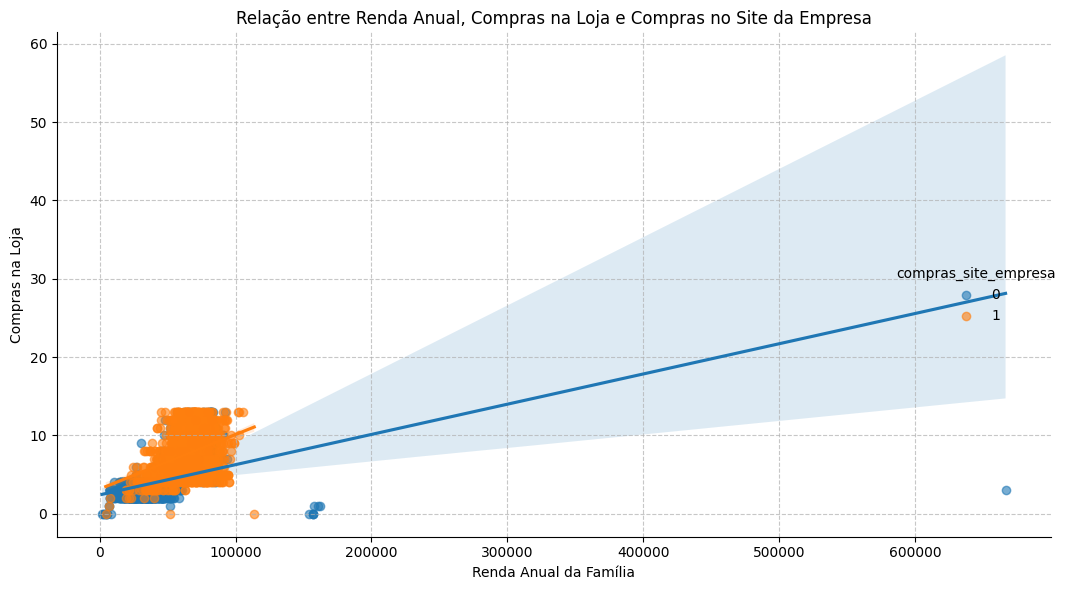

Gráfico de dispersão gerado para 'renda_anual_da_familia' vs 'compras_loja', colorido por 'compras_site_empresa'.


In [20]:
# Criando gráfico de dispersão gerado para 'renda_anual_da_familia' vs 'compras_loja', colorido por 'compras_site_empresa'
plt.figure(figsize=(12, 8))
sns.lmplot(data=base, x='renda_anual_da_familia', y='compras_loja', hue='compras_site_empresa',
           height=6, aspect=1.5, scatter_kws={'alpha':0.6})
plt.title('Relação entre Renda Anual, Compras na Loja e Compras no Site da Empresa')
plt.xlabel('Renda Anual da Família')
plt.ylabel('Compras na Loja')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Gráfico de dispersão gerado para 'renda_anual_da_familia' vs 'compras_loja', colorido por 'compras_site_empresa'.")

## Relação entre Compras na Loja e Renda Anual da Família (Gráfico de Barras Empilhadas):
Este gráfico de barras empilhadas, embora mais descritivo do que correlacional, mostra a distribuição da renda anual da família para diferentes quantidades de compras na loja. Se você observar, em geral, conforme o número de compras_loja aumenta, há uma proporção maior de clientes com renda_anual_da_familia mais alta. Isso sugere que clientes com maior renda tendem a fazer mais compras nas lojas físicas.

## Gráfico de Dispersão: Renda Anual da Família vs. Compras na Loja, Colorido por Compras no Site da Empresa:
Este lmplot (gráfico de dispersão com linha de regressão) é muito útil. Ele revela uma correlação positiva entre renda_anual_da_familia e compras_loja. Clientes com renda mais alta tendem a fazer mais compras na loja física.
A coloração pelos pontos de compras_site_empresa (0: Não Comprou, 1: Comprou) é crucial: você provavelmente notará que os pontos azuis (clientes que compraram online) estão mais concentrados na parte superior direita do gráfico, indicando que clientes com alta renda e que já compram bastante na loja física também são mais propensos a comprar no site da empresa. Isso sugere um perfil de cliente de alto valor e multicanal.

/tmp/ipykernel_162/3669868073.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




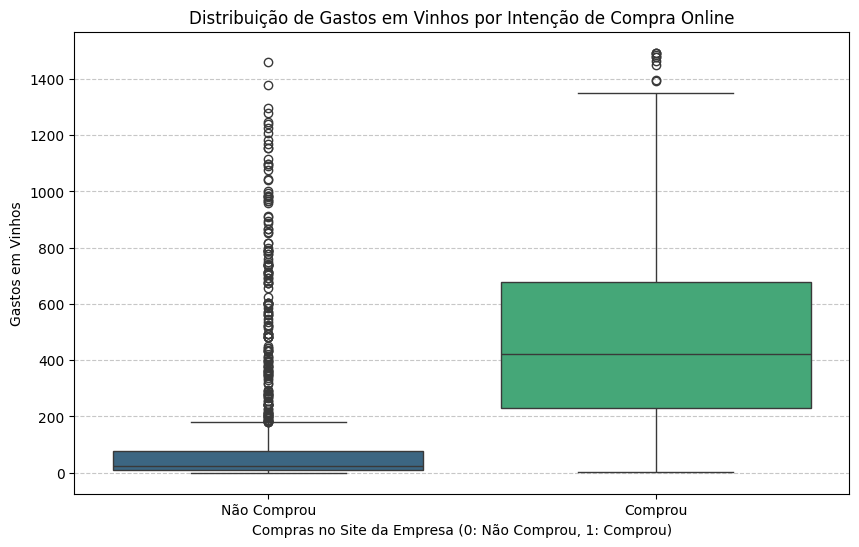

Box plot gerado para 'gasto_em_vinhos' vs 'compras_site_empresa'.


In [21]:
# Box plot para 'gasto_em_vinhos' vs 'compras_site_empresa'
plt.figure(figsize=(10, 6))
sns.boxplot(data=base, x='compras_site_empresa', y='gasto_em_vinhos', palette='viridis')
plt.title('Distribuição de Gastos em Vinhos por Intenção de Compra Online')
plt.xlabel('Compras no Site da Empresa (0: Não Comprou, 1: Comprou)')
plt.ylabel('Gastos em Vinhos')
plt.xticks([0, 1], ['Não Comprou', 'Comprou'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Box plot gerado para 'gasto_em_vinhos' vs 'compras_site_empresa'.")

## Gráfico de Gastos em Vinhos vs. Intenção de Compra Online:
O box plot para gasto_em_vinhos e compras_site_empresa demonstra uma forte correlação positiva. A caixa e os bigodes para o grupo que 'Comprou' (1) estão significativamente mais altos do que para o grupo que 'Não Comprou' (0). Isso indica que clientes que gastam mais em vinhos têm uma propensão muito maior a realizar compras no site da empresa. O gasto com vinhos pode ser um forte indicador do poder aquisitivo ou do estilo de vida desses clientes, que os torna mais propensos a compras online.

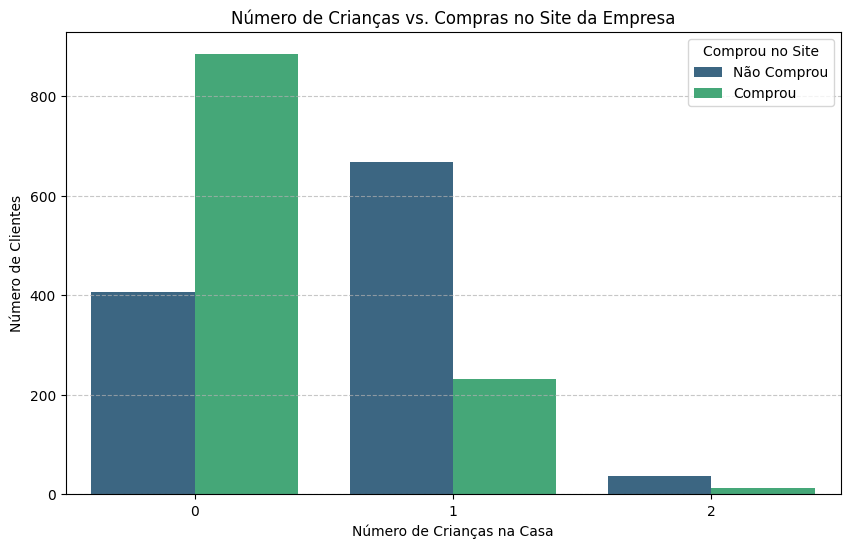

Count plot gerado para 'numero_de_criancas' vs 'compras_site_empresa'.


In [22]:
# Plotando grafico 'Número de Crianças vs. Compras no Site da Empresa'
plt.figure(figsize=(10, 6))
sns.countplot(data=base, x='numero_de_criancas', hue='compras_site_empresa', palette='viridis')
plt.title('Número de Crianças vs. Compras no Site da Empresa')
plt.xlabel('Número de Crianças na Casa')
plt.ylabel('Número de Clientes')
plt.legend(title='Comprou no Site', labels=['Não Comprou', 'Comprou'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Count plot gerado para 'numero_de_criancas' vs 'compras_site_empresa'.")

## A analise do Gráfico 'Número de Crianças vs. Compras no Site da Empresa':
Este countplot mostra uma correlação negativa entre numero_de_criancas e compras_site_empresa. Você pode observar que a proporção de clientes que compraram online (representados por uma das cores na barra) é maior para aqueles com 0 ou 1 criança. Conforme o número de crianças aumenta (2, por exemplo), a proporção de clientes que realizaram compras online tende a diminuir. Isso pode sugerir que famílias com mais crianças têm menos tempo, menos recursos discricionários ou diferentes prioridades de compra que as tornam menos propensas a comprar online na sua plataforma.


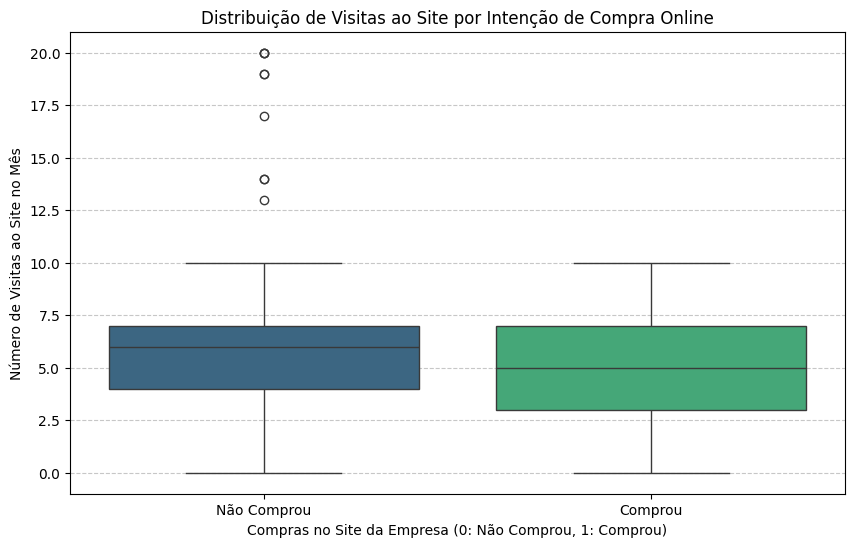

Box plot gerado para 'visitas_site_mes' vs 'compras_site_empresa'.


In [23]:
# Plotando grafico de 'Distribuição de Visitas ao Site' por 'Intenção de Compra Online'
plt.figure(figsize=(10, 6))
sns.boxplot(data=base, x='compras_site_empresa', y='visitas_site_mes', hue='compras_site_empresa', palette='viridis', legend=False)
plt.title('Distribuição de Visitas ao Site por Intenção de Compra Online')
plt.xlabel('Compras no Site da Empresa (0: Não Comprou, 1: Comprou)')
plt.ylabel('Número de Visitas ao Site no Mês')
plt.xticks([0, 1], ['Não Comprou', 'Comprou'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Box plot gerado para 'visitas_site_mes' vs 'compras_site_empresa'.")

## Análise para Distribuição de Visitas ao Site por Intenção de Compra Online:
O box plot mostrou que clientes que fazem compras online tendem a ter uma frequência maior de visitas ao site, sugerindo uma relação direta entre o engajamento com a plataforma online da empresa e a conversão em compras online.

## Conclusão Geral da Análise Bivariada:
* Esses gráficos revelam que o perfil de cliente mais propenso a comprar online tende a ter maior renda, menos filhos, e demonstra maiores gastos em produtos (especialmente vinhos). Além disso, há uma forte conexão entre o engajamento na loja física (mais compras na loja) e a propensão a comprar online para clientes de alta renda.

* Esses insights são valiosos para segmentar clientes e direcionar campanhas de marketing, focando nos perfis que demonstram maior inclinação para a compra online.

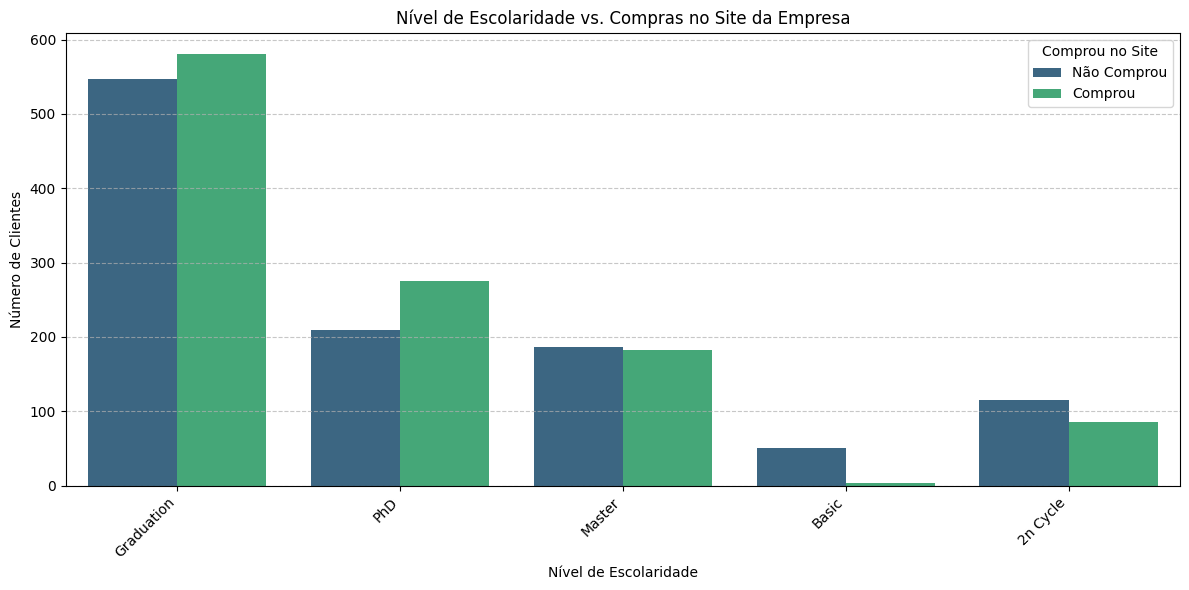

Count plot gerado para 'nivel_de_escolaridade' vs 'compras_site_empresa'.


In [24]:
# Plotando 'nivel_de_escolaridade' vs 'compras_site_empresa'
plt.figure(figsize=(12, 6))
sns.countplot(data=base, x='nivel_de_escolaridade', hue='compras_site_empresa', palette='viridis')
plt.title('Nível de Escolaridade vs. Compras no Site da Empresa')
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Número de Clientes')
plt.legend(title='Comprou no Site', labels=['Não Comprou', 'Comprou'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Count plot gerado para 'nivel_de_escolaridade' vs 'compras_site_empresa'.")

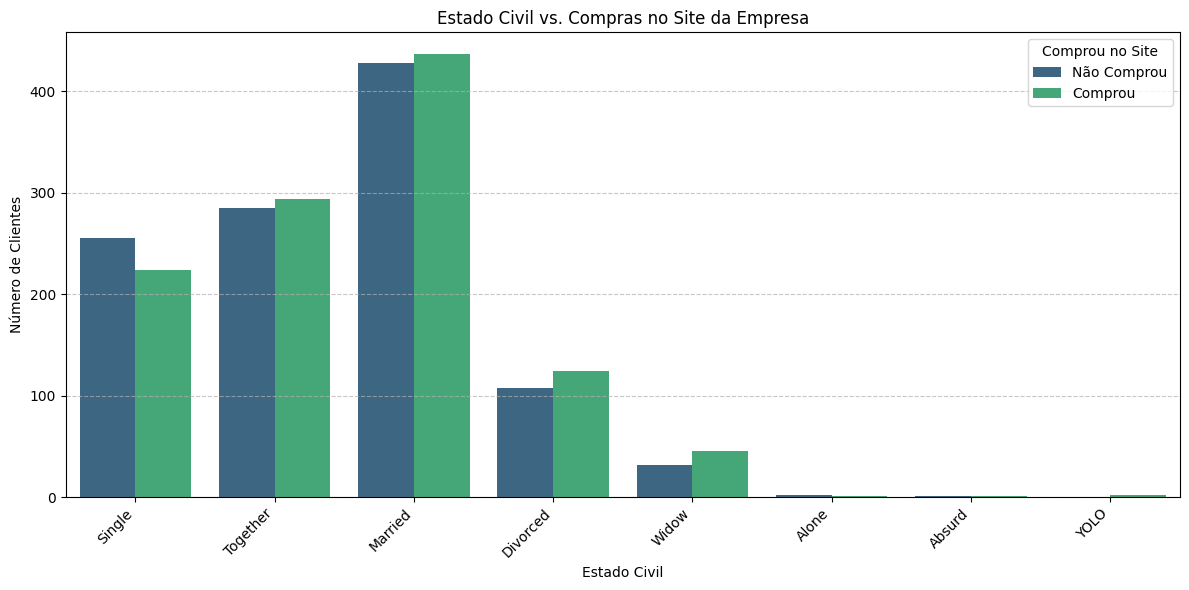

Count plot gerado para 'estado_civil' vs 'compras_site_empresa'.


In [25]:
# Plotando grafico de 'estado civil' vs 'compras no site da empresa'
plt.figure(figsize=(12, 6))
sns.countplot(data=base, x='estado_civil', hue='compras_site_empresa', palette='viridis')
plt.title('Estado Civil vs. Compras no Site da Empresa')
plt.xlabel('Estado Civil')
plt.ylabel('Número de Clientes')
plt.legend(title='Comprou no Site', labels=['Não Comprou', 'Comprou'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Count plot gerado para 'estado_civil' vs 'compras_site_empresa'.")

## Analise Bivariada das variaveis categoricas:

### Nível de Escolaridade vs. Compras no Site da Empresa:

*   **Graduação:** Clientes com nível de graduação representam a maior parcela tanto de compradores quanto de não compradores online. No entanto, a proporção de clientes com graduação que compram online é significativamente alta, indicando que esse grupo é um alvo importante para o e-commerce.
*   **PhD e Master:** Clientes com PhD e Master também mostram uma proporção considerável de compras online, sugerindo que níveis de escolaridade mais altos podem estar associados a uma maior propensão a comprar no site.
*   **Básico e 2n Cycle/2nd Cycle:** A proporção de clientes que compram online entre aqueles com nível de escolaridade básico ou 2n Cycle/2nd Cycle é visivelmente menor em comparação com os outros grupos, indicando que esses segmentos podem precisar de estratégias de engajamento diferentes ou que suas prioridades de compra online são mais baixas.

### Estado Civil vs. Compras no Site da Empresa:

*   **Married e Together:** Clientes casados ou em união estável ('Married' e 'Together') representam a maioria dos clientes em geral. A proporção de compras online para esses grupos é considerável, mas não há uma disparidade tão grande em comparação com os que não compram online dentro desses mesmos grupos, o que pode indicar que o estado civil por si só não é um fator tão determinante quanto a escolaridade, mas sim o volume total de clientes nesses estados.
*   **Single:** Clientes solteiros também mostram uma quantidade razoável de compras online, com uma proporção de compra/não compra que parece seguir a tendência geral.
*   **Divorced e Widow:** Embora em menor número, os clientes divorciados e viúvos também contribuem para as compras online, com proporções que precisam ser consideradas dentro de seu tamanho de grupo. Há alguns casos de estados civis com pouquíssimas ocorrências ('Alone', 'YOLO'), mas que não geram insights significativos devido ao seu baixo volume.

### Insights Gerais:

*   **Nível de Escolaridade** parece ser um fator mais discriminatório na propensão a compras online do que o **Estado Civil**. Clientes com maior escolaridade (Graduação, Master, PhD) tendem a estar mais engajados com compras online.
*   Para **Estado Civil**, os grupos 'Married' e 'Together' dominam em número, o que naturalmente se reflete nos volumes de compras online, mas a *proporção* de compradores online nesses grupos não se destaca tão fortemente em comparação com outros estados civis (exceto talvez 'Basic' na escolaridade). Isso sugere que, embora esses grupos sejam grandes, a intenção de compra online pode ser influenciada por outros fatores mais diretamente relacionados à capacidade de compra ou estilo de vida, conforme visto na análise de renda e número de crianças.

In [26]:
# Retirando variaveis que não tem correlação com a variavel Target
colunas_para_remover = ['reclamacoes', 'ultima_compra']
base = base.drop(colunas_para_remover, axis=1)

**Codificando Variáveis Categóricas:** Transformando variáveis categóricas em um formato que os modelos de machine learning possam interpretar.

In [27]:
import numpy as np

# Agrupar 'nivel_de_escolaridade'
# 1 para Superior (Graduation, Master, PhD, 2n Cycle, 2nd Cycle), 0 para Basico
base['nivel_superior'] = base['nivel_de_escolaridade'].apply(lambda x: 1 if x in ['Graduation', 'Master', 'PhD', '2n Cycle', '2nd Cycle'] else 0)

# Agrupar 'estado_civil'
# 1 para Com Parceria (Married, Together), 0 para Sem Parceria (Single, Divorced, Widow, Alone, YOLO)
base['com_parceria'] = base['estado_civil'].apply(lambda x: 1 if x in ['Married', 'Together'] else 0)

# Excluir as colunas originais de escolaridade e estado civil
base = base.drop(['nivel_de_escolaridade', 'estado_civil'], axis=1)

print("Colunas 'nivel_de_escolaridade' e 'estado_civil' foram codificadas e as colunas originais removidas.")
print(base[['nivel_superior', 'com_parceria']].head())

Colunas 'nivel_de_escolaridade' e 'estado_civil' foram codificadas e as colunas originais removidas.
   nivel_superior  com_parceria
0               1             0
1               1             0
2               1             1
3               1             1
4               1             1


In [28]:
# Verificando base após modificações
base.head()

,renda_anual_da_familia,numero_de_criancas,gasto_em_vinhos,gasto_em_frutas,gasto_em_carnes,gasto_em_peixes,gasto_em_doces,gasto_produtos_ouro,compras_loja,visitas_site_mes,compras_site_empresa,idade,nivel_superior,com_parceria
0,58138.0,0,635,88,546,172,88,88,4,7,1,57,1,0
1,46344.0,1,11,1,6,2,1,6,2,5,0,60,1,0
2,71613.0,0,426,49,127,111,21,42,10,4,1,49,1,1
3,26646.0,1,11,4,20,10,3,5,4,6,0,30,1,1
4,58293.0,1,173,43,118,46,27,15,6,5,1,33,1,1


In [29]:
base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2237 entries, 0 to 2239
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   renda_anual_da_familia  2237 non-null   float64
 1   numero_de_criancas      2237 non-null   int64  
 2   gasto_em_vinhos         2237 non-null   int64  
 3   gasto_em_frutas         2237 non-null   int64  
 4   gasto_em_carnes         2237 non-null   int64  
 5   gasto_em_peixes         2237 non-null   int64  
 6   gasto_em_doces          2237 non-null   int64  
 7   gasto_produtos_ouro     2237 non-null   int64  
 8   compras_loja            2237 non-null   int64  
 9   visitas_site_mes        2237 non-null   int64  
 10  compras_site_empresa    2237 non-null   int64  
 11  idade                   2237 non-null   int64  
 12  nivel_superior          2237 non-null   int64  
 13  com_parceria            2237 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 262.1 

In [30]:
# salvando DataFrame
base.to_csv('campaign_analytics_base.csv', index=False)

In [31]:
# Separando base
X = base.drop('compras_site_empresa', axis=1)
Y = base['compras_site_empresa']

In [32]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# **Iniciando o Modelo Random Forest**

In [33]:
# Iniciando o modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)

In [56]:
# Iniciando Padronização dos dados
scaler = StandardScaler()

In [52]:
# Iniciando Padronização dos dados e Treinando o modelo Random Forest
# Padronizando os dados
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinando o modelo Random Forest com dados padronizados
rf_model.fit(X_train_scaled, Y_train)

RandomForestClassifier(random_state=42)

In [53]:
# Fazendo previsões no conjunto de teste para Random Forest
Y_pred_rf = rf_model.predict(X_test_scaled)

# **Iniciando o Modelo de Regressão Logística**

In [47]:
# Instanciando o modelo de regressão logística
modelo = LogisticRegression(max_iter=1000)

In [42]:
# Determinando o numero de folds
folds = 5

In [58]:
# Configurando o Cross Validation
crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=5)

In [59]:
# Treinando o modelo de Regressão Logística e fazendo previsões
modelo.fit(X_train_scaled, Y_train)
Y_pred_lr = modelo.predict(X_test_scaled)

In [60]:
# Avaliando a pontuação de cada modelo
pontuacoes = cross_val_score(modelo, X, Y, cv=crossvalidation)

print(f"Pontuações por fold: {pontuacoes}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/

Pontuações por fold: [0.83705357 0.82142857 0.81208054 0.79194631 0.7852349 ]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [61]:
# Validando media final do modelo
print((modelo_final.mean()))

0.814043024928092


# **Avaliação de Modelos**

In [63]:
# Avaliando modelos
print("---- Avaliação do Modelo Random Forest ----")
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
report_rf = classification_report(Y_test, Y_pred_rf)
conf_matrix_rf = confusion_matrix(Y_test, Y_pred_rf)

print(f"Acurácia: {accuracy_rf:.2f}")
print("Relatório de Classificação:\n", report_rf)
print("Matriz de Confusão:\n", conf_matrix_rf)

print("\n---- Avaliação do Modelo de Regressão Logística ----")
accuracy_lr = accuracy_score(Y_test, Y_pred_lr)
report_lr = classification_report(Y_test, Y_pred_lr)
conf_matrix_lr = confusion_matrix(Y_test, Y_pred_lr)

print(f"Acurácia: {accuracy_lr:.2f}")
print("Relatório de Classificação:\n", report_lr)
print("Matriz de Confusão:\n", conf_matrix_lr)

---- Avaliação do Modelo Random Forest ----
Acurácia: 0.93
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.95      0.89      0.92       218
           1       0.91      0.96      0.93       230

    accuracy                           0.93       448
   macro avg       0.93      0.93      0.93       448
weighted avg       0.93      0.93      0.93       448

Matriz de Confusão:
 [[195  23]
 [ 10 220]]

---- Avaliação do Modelo de Regressão Logística ----
Acurácia: 0.84
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       218
           1       0.85      0.84      0.85       230

    accuracy                           0.84       448
   macro avg       0.84      0.84      0.84       448
weighted avg       0.84      0.84      0.84       448

Matriz de Confusão:
 [[183  35]
 [ 36 194]]


## Analise de Performance do Modelo Random Forest

* O modelo reagiu muito bem aos dados de teste. A **Acurácia** de 0.93 é um indicativo forte de que o modelo consegue classificar corretamente a grande maioria dos clientes (93%).

* Os valores altos de **Precision** (0.95 para 'Não Comprou' e 0.91 para 'Comprou') e **Recal**l (0.89 para 'Não Comprou' e 0.96 para 'Comprou') mostram que o modelo é eficaz em ambos os lados: minimiza predições falsas e maximiza a identificação correta dos verdadeiros casos.
Especialmente o **Recall** de 0.96 para a classe 'Comprou' é excelente! Isso significa que o modelo é muito bom em identificar clientes que realmente farão uma compra, minimizando as 'oportunidades perdidas' (falsos negativos).

* A **Matriz de Confusão** reforça isso: apenas 10 Falsos Negativos (clientes que comprariam, mas o modelo previu que não) e 23 Falsos Positivos (clientes que não comprariam, mas o modelo previu que sim). Esses números são baixos em relação ao total, indicando um bom desempenho.

## Avaliação do Modelo de Regressão Logística
* A **Acurácia:** 0.84, é uma acurácia razoável, mas significativamente menor que a do Random Forest.
* Relatório de Classificação:
Classe 0 (Não Comprou): **Precision** de 0.84 e Recall de 0.84.
Classe 1 (Comprou): **Precision** de 0.85 e Recall de 0.84.
* A **Matriz de Confusão:** [[183, 35], [36, 194]], 35 Falsos Positivos: Clientes que não comprariam, mas o modelo previu que comprariam. 36 Falsos Negativos: Clientes que comprariam, mas o modelo previu que não (um número maior que o Random Forest).


## Comparação e Conclusão
Ao comparar os dois modelos, fica evidente que o **Random Forest** obteve um desempenho superior em todas as métricas chave:

Acurácia: 0.93 **(Random Forest)** vs. 0.84 **(Regressão Logística)**.

* Identificação de Compradores (Recall da Classe 1): O Random Forest foi muito melhor (0.96) em identificar clientes que realmente comprariam, o que é frequentemente a métrica mais crítica para este tipo de problema de negócio (prevenção de 'oportunidades perdidas'). A Regressão Logística obteve 0.84.

* Erros: O Random Forest teve menos Falsos Positivos (23 vs 35) e significativamente menos Falsos Negativos (10 vs 36).

## Conclusão

O Modelo **Random Forest** realizou as previsões muito melhor para esta base de dados. Sua capacidade de identificar corretamente os clientes com intenção de compra é notavelmente superior, tornando-o a escolha mais adequada para o objetivo do seu projeto.


# **Insights (Foco no Valor de Negócio):**
1. **Poder Preditivo e Otimização de Marketing:**

* **Ponto-chave:** "Desenvolvemos um modelo de Machine Learning (Random Forest) com 93% de acurácia e impressionantes 96% de recall na identificação de clientes com intenção de compra online.
* **Impacto:** Isso significa que a empresa pode identificar com alta precisão seus potenciais compradores, otimizando campanhas de marketing, reduzindo custos com anúncios para quem não tem interesse e aumentando a taxa de conversão ao direcionar ofertas personalizadas para os clientes certos.

2. **Segmentação de Clientes Acionável:**

* Ponto-chave: A análise revelou perfis de clientes claros: aqueles com maior renda, menos filhos, maior gasto em vinhos e níveis de escolaridade mais altos são os mais propensos a comprar online.
* **Impacto:** Esses insights permitem a criação de segmentos de clientes altamente qualificados, possibilitando estratégias de marketing mais eficazes e personalizadas. Por exemplo, campanhas para clientes de alta renda com baixo número de filhos teriam um ROI (Retorno sobre Investimento) potencialmente muito maior.

3. **Engajamento e Experiência do Cliente:**

* **Ponto-chave:** Identificamos que clientes que visitam o site com maior frequência são mais propensos a comprar.
* **Impacto:** Este insight pode guiar iniciativas para melhorar o engajamento no site e a experiência do usuário, convertendo visitantes em compradores. Sugere também que podemos reter clientes já engajados com ações específicas para estimular a compra online."